# SymPyによる制御工学

## 概要

制御工学は、システム（制御対象）の挙動を数学的にモデル化し、望ましい動作を実現するための入力を設計する学問である。この分野において、時間領域（$t$）の複雑な微分方程式を、複素周波数領域（$s$領域）の代数方程式に変換して解析する「ラプラス変換（Laplace Transform）」は、最も基本的かつ強力なツールである。

通常、ラプラス変換やその逆変換、伝達関数の計算は手計算で行うと非常に煩雑であるが、Pythonの数式処理ライブラリ **SymPy** を用いれば、これらの操作を記号的に厳密かつ瞬時に実行できる。さらに、Pythonの数値計算・可視化ライブラリと組み合わせることで、ボード線図の描画やステップ応答のシミュレーションまでを一貫して行うことが可能となる。

本記事では、SymPyを用いた古典制御理論の解析手法について、以下のトピックを詳細に解説する。

1.  **ラプラス変換の基礎**：定義と標準信号の変換
2.  **微分方程式の解法**：バネ・マス・ダンパ系の過渡応答解析
3.  **伝達関数と安定性**：極・零点マップによる安定判別
4.  **周波数応答解析**：ボード線図の作成
5.  **フィードバック制御**：PID制御器の設計と効果

### 筆者の環境
実行環境は以下の通りである。

In [1]:
!sw_vers

ProductName:		macOS
ProductVersion:		15.5
BuildVersion:		24F74


In [2]:
!python -V

Python 3.12.12


必要なライブラリをインポートする。SymPyの変換モジュール `sympy.integrals.transforms` が中核となる。

In [3]:
import sympy
from sympy import symbols, Function, exp, sin, cos, Heaviside, plot, simplify, expand, factor, sqrt, log, atan2, Abs, re, im, I
from sympy.integrals.transforms import laplace_transform, inverse_laplace_transform
from sympy.abc import t, s, a, omega
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

sympy.init_printing()
print(f"SymPy Version: {sympy.__version__}")

SymPy Version: 1.14.0


## 1. ラプラス変換の基礎

時間関数 $f(t) (t \ge 0)$ のラプラス変換 $F(s) = \mathcal{L}\{f(t)\}$ は以下のように定義される。

$$ F(s) = \int_0^\infty f(t) e^{-st} dt $$

SymPyの `laplace_transform` 関数は `(F(s), 収束領域, 条件)` のタプルを返すが、通常の実用計算では第1要素のみが必要となる。ここでは使いやすいラッパー関数を定義しておく。

In [4]:
def L(f):
    return laplace_transform(f, t, s, noconds=True)

def invL(F):
    return inverse_laplace_transform(F, s, t)

### 1.1 標準信号の変換

制御工学で頻出する信号（単位ステップ、ランプ、指数減衰、正弦波）を変換してみる。

基本関数のラプラス変換:
Step: Heaviside(t) ->


--------------------
Ramp: t ->


--------------------
Exponential: exp(-a*t) ->


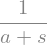

--------------------
Sine: sin(omega*t) ->


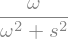

--------------------


In [5]:
u = Heaviside(t) # 単位ステップ関数
ramp = t         # ランプ関数
decay = exp(-a*t)
osc = sin(omega*t)

funcs = [u, ramp, decay, osc]
names = ['Step', 'Ramp', 'Exponential', 'Sine']

print("基本関数のラプラス変換:")
for name, f in zip(names, funcs):
    fs = L(f)
    print(f"{name}: {f} ->")
    display(fs)
    print("-" * 20)

指数関数 $e^{-at}$ が $\frac{1}{s+a}$ に、正弦波 $\sin(\omega t)$ が $\frac{\omega}{s^2+\omega^2}$ に変換されるなど、教科書通りの結果が得られる。

## 2. 微分方程式の解法：バネ・マス・ダンパ系

ラプラス変換の最大の利点は、「微積分演算が代数演算に置き換わる」ことにある。

$$ \mathcal{L}\{\dot{f}(t)\} = s F(s) - f(0) $$
$$ \mathcal{L}\{\ddot{f}(t)\} = s^2 F(s) - s f(0) - \dot{f}(0) $$

これを用いて、以下の2階線形微分方程式（減衰振動系）を解く。

$$ \ddot{x}(t) + 2 \zeta \omega_n \dot{x}(t) + \omega_n^2 x(t) = 0 $$

ここで $\zeta$ (ゼータ) は減衰係数、$\omega_n$ は固有角振動数である。初期条件は $x(0)=1, \dot{x}(0)=0$ とする。

In [6]:
x = Function('x')(t)
zeta = symbols('zeta', real=True, positive=True)
wn = symbols('omega_n', real=True, positive=True)
X = symbols('X') # ラプラス変換後の x(t)

# 初期条件
x0 = 1
v0 = 0

# 微分方程式のラプラス変換形
# x'' -> s^2 X - s x0 - v0
# x'  -> s X - x0
L_eq = (s**2 * X - s*x0 - v0) + 2*zeta*wn * (s*X - x0) + wn**2 * X

# 代数方程式を X について解く
X_sol = solve(L_eq, X)[0]

print("s領域での解 X(s):")
display(X_sol)

NameError: name 'solve' is not defined

求まった $X(s)$ を逆ラプラス変換すれば、時間領域の解 $x(t)$ が得られる。具体的な数値（$\omega_n=1$）を設定し、減衰係数 $\zeta$ を変化させたときの挙動を可視化する。

In [ ]:
# 時間領域に戻す（逆変換）
# zetaの値によって式の形が変わるため、数値を代入してから逆変換する

zetas = [0.2, 0.5, 1.0, 2.0]
t_vals = np.linspace(0, 15, 300)

plt.figure(figsize=(10, 6))

for z in zetas:
    # パラメータ代入
    X_sub = X_sol.subs({wn: 1, zeta: z})
    # 逆変換
    x_t = invL(X_sub)
    # 数値計算用にラムダ化
    f_xt = sympy.lambdify(t, x_t, 'numpy')

    plt.plot(t_vals, f_xt(t_vals), label=f'$\zeta={z}$')

plt.title(r'Time Response: $\ddot{x} + 2\zeta\omega_n\dot{x} + \omega_n^2 x = 0$')
plt.xlabel('Time t')
plt.ylabel('Displacement x(t)')
plt.grid()
plt.legend()
plt.show()

$\zeta < 1$ で減衰振動、$\zeta = 1$ で臨界減衰、$\zeta > 1$ で過減衰となる様子が明確に確認できる。

## 3. 伝達関数と極・零点解析

システムの入力 $U(s)$ と出力 $Y(s)$ の比 $G(s) = \frac{Y(s)}{U(s)}$ を伝達関数と呼ぶ。
分母多項式 $D(s)=0$ の根を「極（Pole）」、分子多項式 $N(s)=0$ の根を「零点（Zero）」といい、極の位置はシステムの安定性を決定づける。

例として以下の3次システムを考える。

$$ G(s) = \frac{2(s+2)}{(s+1)(s^2 + 2s + 5)} $$

In [ ]:
G = 2*(s + 2) / ((s + 1)*(s**2 + 2*s + 5))

print("伝達関数 G(s):")
display(G)

# 極と零点の計算
numerator, denominator = sympy.fraction(G)
zeros = solve(numerator, s)
poles = solve(denominator, s)

print("零点:", zeros)
print("極:", poles)

極は $-1$ と $-1 \pm 2j$ である。全ての実部が負であるため、このシステムは安定である。
これを複素平面上にプロットしたものが「極零点配置図（Pole-Zero Map）」である。

In [ ]:
# 複素数を実部と虚部に分ける
p_real = [sympy.re(p) for p in poles]
p_imag = [sympy.im(p) for p in poles]
z_real = [sympy.re(z) for z in zeros]
z_imag = [sympy.im(z) for z in zeros]

plt.figure(figsize=(6, 6))
plt.scatter(p_real, p_imag, marker='x', s=100, color='red', label='Poles')
plt.scatter(z_real, z_imag, marker='o', s=100, facecolors='none', edgecolors='blue', label='Zeros')

plt.axvline(0, color='black', linewidth=0.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Pole-Zero Map')
plt.xlabel('Real Axis')
plt.ylabel('Imaginary Axis')
plt.grid()
plt.legend()
plt.xlim(-3, 1)
plt.ylim(-3, 3)
plt.show()

## 4. 周波数応答解析：ボード線図

システムに正弦波入力 $u(t) = \sin(\omega t)$ を加えたとき、定常状態での出力振幅倍率 $M(\omega)$ と位相差 $\phi(\omega)$ は、$G(j\omega)$ によって与えられる。

$$ G(j\omega) = |G(j\omega)| e^{j \angle G(j\omega)} $$

SymPyを用いて $G(j\omega)$ の絶対値と偏角を計算し、ボード線図（Bode Plot）を描画する。

In [ ]:
# s に j*omega を代入
G_jw = G.subs(s, I * omega)

# 振幅 (Magnitude) と 位相 (Phase)
mag = Abs(G_jw)
phase = sympy.arg(G_jw) * 180 / sympy.pi # 度数法に変換

# 数値計算用関数
f_mag = sympy.lambdify(omega, mag, 'numpy')
f_phase = sympy.lambdify(omega, phase, 'numpy')

w_vals = np.logspace(-2, 2, 500)
mag_vals = 20 * np.log10(f_mag(w_vals)) # dB変換
phase_vals = f_phase(w_vals)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ゲイン線図
ax1.semilogx(w_vals, mag_vals)
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('Bode Plot')
ax1.grid(which='both', linewidth=0.5)

# 位相線図
ax2.semilogx(w_vals, phase_vals)
ax2.set_ylabel('Phase (deg)')
ax2.set_xlabel('Frequency (rad/s)')
ax2.grid(which='both', linewidth=0.5)
ax2.set_ylim(-180, 0)

plt.show()

低周波域でのゲイン特性や、共振周波数付近でのピーク、位相遅れなどの特性が一目でわかる。Pythonなら、専門ツールを使わずともSymPyだけでここまでの解析が可能である。

## 5. 応用：PID制御器の設計

最後に、フィードバック制御系の設計例を示す。
制御対象 $P(s) = \frac{1}{s(s+1)}$ に対し、PID制御器 $C(s) = K_p + \frac{K_i}{s} + K_d s$ を直列に接続し、フィードバック系を構成する。

一巡伝達関数 $L(s) = C(s)P(s)$、閉ループ伝達関数 $T(s) = \frac{L(s)}{1+L(s)}$ となる。
ここでは簡単のため、P制御（$K_p=10, K_i=0, K_d=0$）とPD制御（$K_p=10, K_d=2$）のステップ応答を比較する。

In [ ]:
Kp, Kd = symbols('K_p K_d', real=True, positive=True)
P_plant = 1 / (s * (s + 1))

# PD制御器 (積分項 Ki=0 とする)
C_ctrl = Kp + Kd * s

# 一巡伝達関数
L_loop = C_ctrl * P_plant

# 閉ループ伝達関数
T_closed = L_loop / (1 + L_loop)
T_closed = simplify(T_closed)

print("閉ループ伝達関数 T(s):")
display(T_closed)

# ステップ応答 Y(s) = T(s) * (1/s)
Y_resp = T_closed * (1/s)

# 逆変換して時間関数 y(t) を求めるための関数
def get_step_response(kp_val, kd_val):
    Y_sub = Y_resp.subs({Kp: kp_val, Kd: kd_val})
    y_t = invL(Y_sub)
    return sympy.lambdify(t, y_t, 'numpy')

# シミュレーション
f_p_only = get_step_response(10, 0) # P制御
f_pd     = get_step_response(10, 2) # PD制御

t_sim = np.linspace(0, 5, 200)
y_p = f_p_only(t_sim)
y_pd = f_pd(t_sim)

plt.figure(figsize=(10, 6))
plt.plot(t_sim, y_p, label='P Control (Kp=10)')
plt.plot(t_sim, y_pd, label='PD Control (Kp=10, Kd=2)')
plt.axhline(1, color='black', linestyle='--', label='Target')
plt.title('Step Response: P vs PD Control')
plt.xlabel('Time t')
plt.ylabel('Output y(t)')
plt.grid()
plt.legend()
plt.show()

P制御のみでは振動的（オーバーシュートが大きい）だが、微分項（D制御）を追加することで制動が効き、速やかに目標値に収束していることがわかる。このようにSymPyを使えば、制御パラメータの変更がシステム応答に与える影響を解析的に、かつ視覚的に確認できる。

## 結論

この記事では、SymPyを用いた制御工学の問題解決フローを解説した。

1.  **ラプラス変換**: `laplace_transform` により、微分方程式を代数的に扱える形式へ変換した。
2.  **システムの解析**: 伝達関数から極・零点を求め、またボード線図を描くことで、安定性や周波数特性を評価した。
3.  **制御器設計**: 閉ループ系のステップ応答を計算し、PIDパラメータの効果をシミュレーションした。

SymPyは、単なる計算機としてだけでなく、制御理論の深い理解を助けるための教育的ツールとしても、また実務における初期設計ツールとしても極めて有用である。

### 参考文献

*   [SymPy Documentation: Integral Transforms](https://docs.sympy.org/latest/modules/integrals/integrals.html)
*   Ogata, K. (2010). *Modern Control Engineering*.